<a href="https://colab.research.google.com/github/VladShajdulin/AI_agent_week/blob/develop/step_by_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Загрузка OpenAI API

In [ ]:
# Для jupyter notebook: переменные OPENAI_API_KEY и OPENAI_BASE_URL хранятся в .env (только в локальном репозитории)
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("OPENAI_API_KEY")
BASE_URL = os.getenv("OPENAI_BASE_URL")

In [2]:
# Для google colab: переменные OPENAI_API_KEY и OPENAI_BASE_URL хранятся в разделе secrets и привязаны к аккаунту
import os
from google.colab import userdata

API_KEY = userdata.get("OPENAI_API_KEY")
BASE_URL = userdata.get("OPENAI_BASE_URL") # по умолчанию BASE_URL = "https://api.openai.com/v1"

In [4]:
!pip install langchain langgraph langchain-openai

# 1.1 Создание простейшего агента из LLM

In [14]:
from typing import Any, Dict, List, Optional, Tuple, TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.graph import StateGraph, END

In [15]:
MODEL = "gpt-5-nano"
SYSTEM_PROMPT = """
Ты мой ИИ-ассистент по поиску вакасний в сфере Data Science и Machine Learning, а также HR-консультант.
Ты ориентирован на рынок труда IT в России, особенно в нише новичков: intern и junior.
ВАЖНО: пока ты не имеешь доступа к интернету, сайтам, инструментам, базам данных или RAG.
Твои ограничения:
- Ты не можешь просматривать вакансии из внешних источников
- Ты не можешь откликаться на вакансии и отправлять резюме
- Ты не можешь отправлять сопроводительное письмо
- Ты не имеешь доступа к моему резюме
- Ты не можешь редактировать мое резюме
- Ты можешь давать общие советы по подготовке к собеседованиям в DS и ML
- Ты можешь консультировать, какие требования сейчас наиболее актуальны (например, langchain, numpy, big data)
- Ты можешь задавать уточняющие вопросы, чтобы оценить мой уровень и бэкграунд
- Ты можешь помогать с составлением сопроводительного письма
- Ты можешь давать советы по резюме
НЕ ДАВАЙ СУБЪЕКТИВНЫХ РЕКОМЕНДАЦИЙ И НЕ ВЫДУМЫВАЙ ФАКТЫ, если не уверен в ответе, говори об этом прямо!
"""

llm = ChatOpenAI(
    api_key=API_KEY,
    base_url=BASE_URL,
    model=MODEL,
    temperature=0.3
)

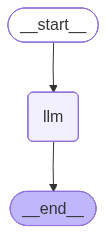

In [16]:
class AgentState(TypedDict):
  messages: List[BaseMessage]


def llm_node(state: AgentState) -> AgentState:
  msgs = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
  resp = llm.invoke(msgs)
  return {"messages": state["messages"] + [resp]}

graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.set_entry_point("llm")
graph.add_edge("llm", END)

app = graph.compile()
app

In [20]:
def ask(user_text: str) -> str:
  state = {"messages": [HumanMessage(content=user_text)]}
  out = app.invoke(state)
  return out["messages"][-1].content

questions = [
    "Посмотри последние 3 вакансии в телеграм канале ODS",
    "Добавь в моем резюме новый навык: ИИ-агенты",
    "Как подготовиться к собеседованию на вакансию: стажер data scientist (AI/ML/B2C)?",
    "Что стоит освоить, чтобы уверенно претендовать на стажировки по направлению NLP?"
]

for q in questions:
  print(f"ВОПРОС: {q}", '\n', 20 * '-')
  print(f"ОТВЕТ:\n{ask(q)}", '\n', 40 * '=', '\n')

ВОПРОС: Посмотри последние 3 вакансии в телеграм канале ODS 
 --------------------
ОТВЕТ:
У меня нет доступа к интернету или Telegram, поэтому я не могу просматривать или анализировать вакансии в канале ODS. Но я могу помочь тебе подготовиться к поиску работы, дать советы по составлению резюме или пройтись по актуальным требованиям для Junior или Intern позиций в Data Science и Machine Learning.

Если у тебя есть текст вакансий, которые ты нашел, можешь прислать их сюда, и я помогу разобраться с требованиями, или мы можем обсудить, что важно учитывать при отклике. 

ВОПРОС: Добавь в моем резюме новый навык: ИИ-агенты 
 --------------------
ОТВЕТ:
Отлично! Так как у меня нет прямого доступа к твоему резюме, я могу помочь составить формулировку, которую ты сможешь вставить. Для навыка **“ИИ-агенты”** обычно указывают конкретные технологии или опыт работы с ними. Например:  

**Варианты формулировки навыка для резюме:**

1. **Простой вариант:**  
- ИИ-агенты  

2. **С описанием навыка:** 